In [61]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
from colorama import Fore
import os

In [2]:
df=pd.read_csv('../data/raw/insurance.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.sample()

,age,sex,bmi,children,smoker,region,charges
856,48,female,33.11,0,yes,southeast,40974.1649


## Check For Duplicates

In [5]:
df.duplicated().sum()

np.int64(1)

In [6]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [7]:
df.drop_duplicates(inplace=True)

<hr>

# EDA 

In [23]:
cat_columns=df.select_dtypes(include='O').columns
num_columns=df.select_dtypes(exclude='O').columns
num_columns, cat_columns

(Index(['age', 'bmi', 'children', 'charges'], dtype='object'),
 Index(['sex', 'smoker', 'region'], dtype='object'))

In [24]:
def Check_uniques(colums_list:list,Columns_type:str):
    print(f'Checking {Columns_type} unique Values :')
    for i in colums_list:
        print(f'{i} unique Values are : {df[i].unique()}')

## Check uniques For Categorical and Numerical Columns :

In [25]:
Check_uniques(cat_columns,'Categorical Columns')

Checking Categorical Columns unique Values :
sex unique Values are : ['female' 'male']
smoker unique Values are : ['yes' 'no']
region unique Values are : ['southwest' 'southeast' 'northwest' 'northeast']


In [26]:
Check_uniques(num_columns,'Numerical Columns')

Checking Numerical Columns unique Values :
age unique Values are : [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
bmi unique Values are : [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.17  23.37  37.

## Checking Description of Numerical Columns : 

In [27]:
for i in num_columns:
    print(f'{i} description is : \n {df[i].describe()}')

age description is : 
 count    1337.000000
mean       39.222139
std        14.044333
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64
bmi description is : 
 count    1337.000000
mean       30.663452
std         6.100468
min        15.960000
25%        26.290000
50%        30.400000
75%        34.700000
max        53.130000
Name: bmi, dtype: float64
children description is : 
 count    1337.000000
mean        1.095737
std         1.205571
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         5.000000
Name: children, dtype: float64
charges description is : 
 count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64


<hr>

# Visualiztion :

In [28]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [31]:
df.drop(columns='charges').columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')

In [34]:
px.histogram(df,x='charges',title='Charges Distribution')

In [35]:
px.histogram(df,x='age',title='Age Distribution')

In [38]:
num_columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

<Axes: xlabel='charges', ylabel='children'>

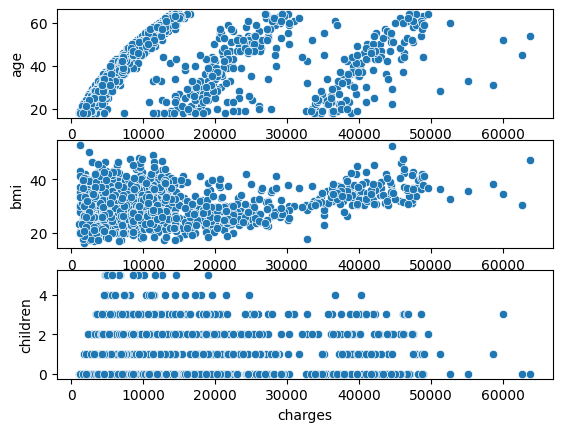

In [46]:
plt.subplot(3,1,1)
sns.scatterplot(df,x='charges',y='age')
plt.subplot(3,1,2)
sns.scatterplot(df,x='charges',y='bmi')
plt.subplot(3,1,3)
sns.scatterplot(df,x='charges',y='children')

In [47]:
cat_columns

Index(['sex', 'smoker', 'region'], dtype='object')

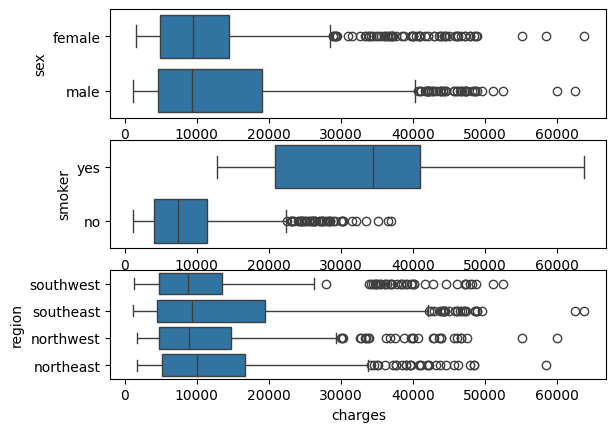

In [52]:
for i,count in zip(cat_columns,range(1,4)) :
    plt.subplot(3,1,count)
    sns.boxplot(df,x='charges',y=i)



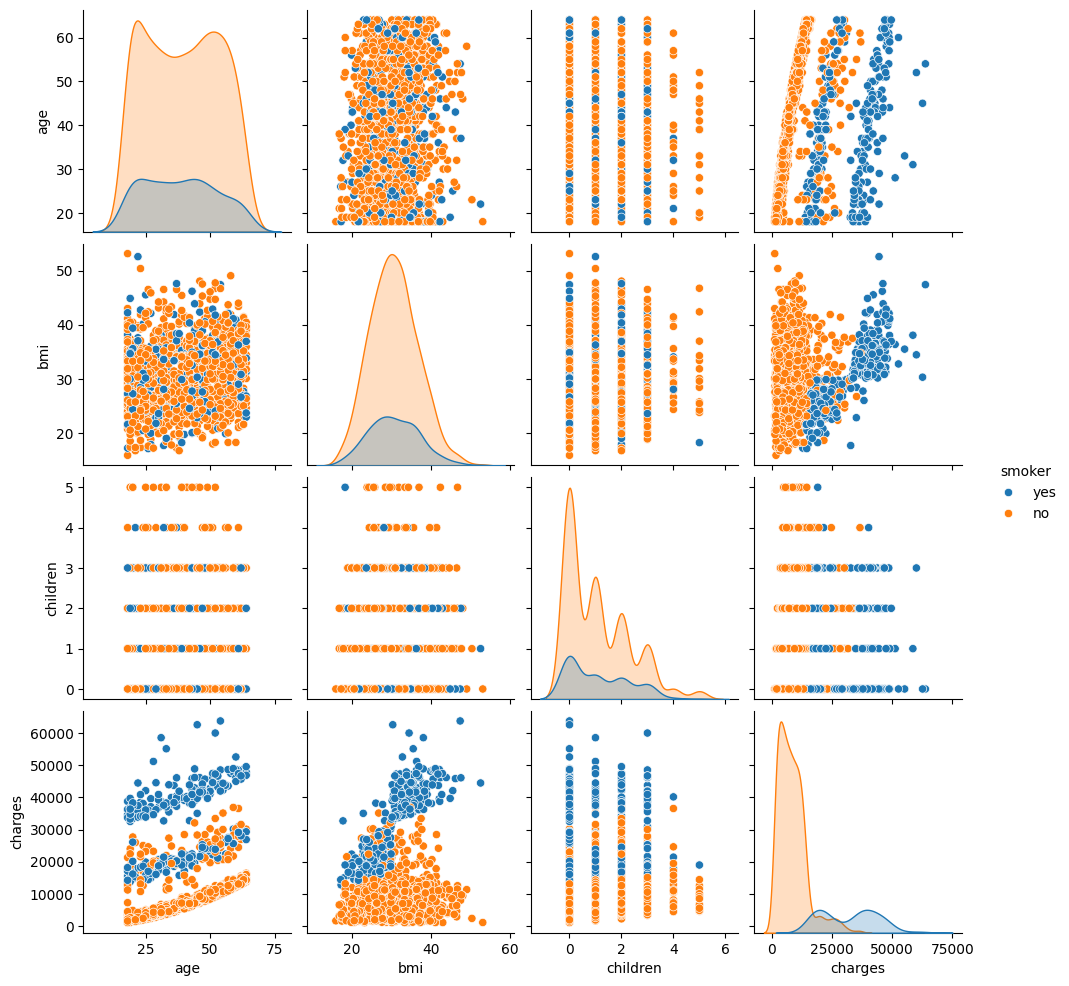

In [57]:
sns.pairplot(df,hue='smoker')


In [59]:
corr=df.corr(numeric_only=True)
corr

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


<Axes: >

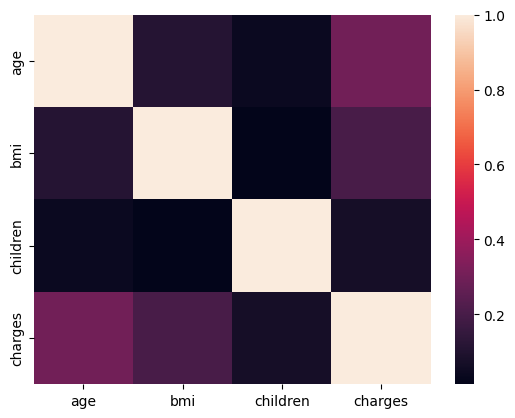

In [60]:
sns.heatmap(corr)

In [62]:
os.listdir()

['EDA.ipynb']

In [63]:
df.to_csv('../data/cleaned/cleaned_data.csv')